### import and path

In [42]:
!pip list |grep Shapely


13250.69s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Shapely                  1.8.4


In [13]:
import socket
import sys
import pickle
import os
import time
from pprint import pprint

sys.path.append('/home/lxh/dev/DRL-urban-planning')
home_dir= '/home/lxh/dev/DRL-urban-planning/'
root_dir = '/home/lxh/dev/DRL-urban-planning/output_urban_planning/'

### demo

In [15]:
from urban_planning.envs import CityEnv
from urban_planning.envs import city_config
from urban_planning.utils.config import Config

In [17]:
id = 'grid3'
seed = 111
temp = False
cfg = Config(id, seed, temp, root_dir)
env = CityEnv(cfg)

Carbon emissions:
{4: 248, 8: 345.9, 5: 193, 6: 906, 7: 0, 9: 321, 10: 20, 11: 18, 12: 20}


In [18]:
init_plan_path = os.path.join(home_dir, 'urban_planning/cfg/test_data/synthetic/init_plan_grid3.pickle')
d= pickle.load(open(init_plan_path, 'rb'))
#d['gdf'].to_file('init_grid2.geojson', driver='GeoJSON')

In [8]:
print(d['gdf'])

    id  type  existence                                           geometry
0    1    13       True                            POINT (0.00000 0.00000)
1    2    13       True                         POINT (1000.00000 0.00000)
2    3    13       True                      POINT (1000.00000 1000.00000)
3    4    13       True                         POINT (0.00000 1000.00000)
4    9     1       True  POLYGON ((0.00000 0.00000, 1000.00000 0.00000,...
5   12    13       True                      POINT (1000.00000 2000.00000)
6   13    13       True                         POINT (0.00000 2000.00000)
7   18     1       True  POLYGON ((0.00000 1000.00000, 1000.00000 1000....
8   20    13       True                         POINT (2000.00000 0.00000)
9   21    13       True                      POINT (2000.00000 1000.00000)
10  27     1       True  POLYGON ((1000.00000 0.00000, 2000.00000 0.000...
11  30    13       True                      POINT (2000.00000 2000.00000)
12  36     1       True  

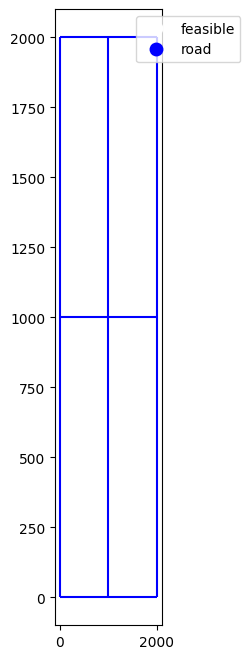

In [19]:
env.load_plan(d['gdf'])
env.visualize()

In [20]:
model_path = os.path.join(root_dir, id, str(seed), 'models', 'best_reward-6.99_iteration_0002.p')
d = pickle.load(open(model_path, 'rb'))
print(d['best_plans'][0])
gdf = d['best_plans'][0]['gdf']
#gdf.plot()

{'road_network': -1.0, 'life_circle': 0.5996734744137922, 'greenness': -1.0, 'concept': -1.0, 'carbon_emission': 9.392315, 'life_circle_info': {'life_circle_15min': 0.8320000000000002, 'life_circle_10min': 0.584, 'life_circle_5min': 0.2, 'life_circle_10min_area': 0.4955498344979772, 'decentralization_reward': 0.31346948827584475, 'utility': 0.24525, 'shopping': 0.72, 'working': 0.72, 'education': 0.4, 'medical care': 0.16, 'entertainment': 0.92}, 'concept_info': {}, 'land_use_reward': -6.993621102344831, 'gdf':       id  type  existence                                           geometry  \
0    1.0    13       True                                POINT (0.000 0.000)   
1    2.0    13       True                             POINT (1000.000 0.000)   
2    3.0    13       True                          POINT (1000.000 1000.000)   
3    4.0    13       True                             POINT (0.000 1000.000)   
4    9.0     1      False  POLYGON ((0.000 0.000, 250.000 0.000, 850.000 ...   
.. 

### load plan and score

In [21]:
env.load_plan(gdf)
env.score_plan()

reward: -6.993621102344831
{   'road_network': -1.0,
    'life_circle': 0.5996734744137922,
    'greenness': -1.0,
    'carbon_emission': 9.392315,
    'road_network_info': {},
    'life_circle_info': {   'life_circle_15min': 0.8320000000000002,
                            'life_circle_10min': 0.584,
                            'life_circle_5min': 0.2,
                            'life_circle_10min_area': 0.4955498344979772,
                            'decentralization_reward': 0.31346948827584475,
                            'utility': 0.24525,
                            'shopping': 0.72,
                            'working': 0.72,
                            'education': 0.4,
                            'medical care': 0.16,
                            'entertainment': 0.92}}


(-6.993621102344831,
 {'road_network': -1.0,
  'life_circle': 0.5996734744137922,
  'greenness': -1.0,
  'carbon_emission': 9.392315,
  'road_network_info': {},
  'life_circle_info': {'life_circle_15min': 0.8320000000000002,
   'life_circle_10min': 0.584,
   'life_circle_5min': 0.2,
   'life_circle_10min_area': 0.4955498344979772,
   'decentralization_reward': 0.31346948827584475,
   'utility': 0.24525,
   'shopping': 0.72,
   'working': 0.72,
   'education': 0.4,
   'medical care': 0.16,
   'entertainment': 0.92}})

In [ ]:
import urban_planning.envs.city_config as city_config
env.visualize()

ValueError: Invalid RGBA argument: 'darkyellow'

Error in callback <function _draw_all_if_interactive at 0x7f0bc2c81ca0> (for post_execute), with arguments args (),kwargs {}:


ValueError: Invalid RGBA argument: 'darkyellow'

ValueError: Invalid RGBA argument: 'darkyellow'

<Figure size 1200x800 with 1 Axes>

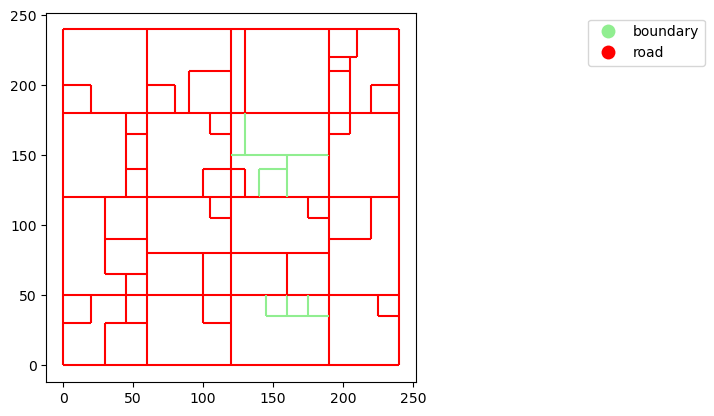

In [16]:
env.visualize_road_and_boundary()

In [10]:
import geojson

features = []

# 区域尺寸
length = 2000  # 米
width = 2000   # 米
grid_size = 1000  # 米

id_counter = 1

# 生成小正方形的顶点和边
for x in range(0, length, grid_size):
    for y in range(0, width, grid_size):
        # 定义四个顶点坐标
        v1 = [x, y]
        v2 = [x + grid_size, y]
        v3 = [x + grid_size, y + grid_size]
        v4 = [x, y + grid_size]

        # 创建顶点要素，类型为 13
        for vx, vy in [v1, v2, v3, v4]:
            point = geojson.Point([vx, vy])
            feature = geojson.Feature(
                geometry=point,
                properties={
                    "id": id_counter,
                    "type": 13,
                    "existence": True
                }
            )
            features.append(feature)
            id_counter += 1

        # 创建边要素，类型为 2
        edges = [
            [v1, v2],
            [v2, v3],
            [v3, v4],
            [v4, v1]
        ]
        for edge in edges:
            line = geojson.LineString(edge)
            feature = geojson.Feature(
                geometry=line,
                properties={
                    "id": id_counter,
                    "type": 2,
                    "existence": True
                }
            )
            features.append(feature)
            id_counter += 1

        # 可选：创建小正方形的多边形要素（如果需要）
        polygon = geojson.Polygon([[v1, v2, v3, v4, v1]])
        feature = geojson.Feature(
            geometry=polygon,
            properties={
                "id": id_counter,
                "type": 1,  # 多边形类型，可根据需要调整
                "existence": True
            }
        )
        features.append(feature)
        id_counter += 1

# 创建 FeatureCollection
feature_collection = geojson.FeatureCollection(features)

# 保存为 geojson 文件
with open('output.geojson', 'w') as f:
    geojson.dump(feature_collection, f)

In [60]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 加载 GeoJSON 文件
gdf = gpd.read_file('output.geojson')

# 查看前几行数据
print(gdf.head())

# 查看数据的概述
#print(gdf.info())



   id  type  existence                                           geometry
0   1    13       True                                POINT (0.000 0.000)
1   2    13       True                             POINT (1000.000 0.000)
2   3    13       True                          POINT (1000.000 1000.000)
3   4    13       True                             POINT (0.000 1000.000)
4   9     1       True  POLYGON ((0.000 0.000, 1000.000 0.000, 1000.00...


In [61]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   id         25 non-null     int64   
 1   type       25 non-null     int64   
 2   existence  25 non-null     bool    
 3   geometry   25 non-null     geometry
dtypes: bool(1), geometry(1), int64(2)
memory usage: 753.0 bytes


In [44]:
gdf=gdf.drop_duplicates(subset='geometry')

In [45]:
gdf[gdf['type']==13]

,id,type,existence,geometry
0,1,13,True,POINT (0.00000 0.00000)
1,2,13,True,POINT (1000.00000 0.00000)
2,3,13,True,POINT (1000.00000 1000.00000)
3,4,13,True,POINT (0.00000 1000.00000)
11,12,13,True,POINT (1000.00000 2000.00000)
12,13,13,True,POINT (0.00000 2000.00000)
19,20,13,True,POINT (2000.00000 0.00000)
20,21,13,True,POINT (2000.00000 1000.00000)
29,30,13,True,POINT (2000.00000 2000.00000)


In [62]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   id         25 non-null     int64   
 1   type       25 non-null     int64   
 2   existence  25 non-null     bool    
 3   geometry   25 non-null     geometry
dtypes: bool(1), geometry(1), int64(2)
memory usage: 753.0 bytes


In [33]:
import geopandas as gpd
from shapely.geometry import LineString
# 定义一个函数来规范化LineString
def normalize_linestring(ls):
    print(ls)
    coords = list(ls.coords)
    if len(coords) < 2:
        raise ValueError("LineStrings must have at least 2 coordinate tuples")
    return LineString(coords) if coords[0] < coords[-1] else LineString(coords[::-1])

# 应用规范化函数
gdf_line=gdf[gdf['type']==2]
gdf_line['normalized_geometry'] = gdf_line['geometry'].apply(normalize_linestring)

# 删除重复的LineString
gdf_line = gdf_line.drop_duplicates(subset='normalized_geometry')

# 删除辅助列
gdf_line = gdf_line.drop(columns='normalized_geometry')

print(gdf_line)

LINESTRING (0 0, 1000 0)
LINESTRING (1000 0, 1000 1000)
LINESTRING (1000 1000, 0 1000)
LINESTRING (0 1000, 0 0)
LINESTRING (0 1000, 1000 1000)
LINESTRING (1000 1000, 1000 2000)
LINESTRING (1000 2000, 0 2000)
LINESTRING (0 2000, 0 1000)
LINESTRING (1000 0, 2000 0)
LINESTRING (2000 0, 2000 1000)
LINESTRING (2000 1000, 1000 1000)
LINESTRING (1000 1000, 1000 0)
LINESTRING (1000 1000, 2000 1000)
LINESTRING (2000 1000, 2000 2000)
LINESTRING (2000 2000, 1000 2000)
LINESTRING (1000 2000, 1000 1000)
    id  type  existence                                           geometry
4    5     2       True   LINESTRING (0.00000 0.00000, 1000.00000 0.00000)
5    6     2       True  LINESTRING (1000.00000 0.00000, 1000.00000 100...
6    7     2       True  LINESTRING (1000.00000 1000.00000, 0.00000 100...
7    8     2       True   LINESTRING (0.00000 1000.00000, 0.00000 0.00000)
14  15     2       True  LINESTRING (1000.00000 1000.00000, 1000.00000 ...
15  16     2       True  LINESTRING (1000.00000 2000.0

/home/lxh/anaconda3/envs/urban3/lib/python3.9/site-packages/geopandas/geodataframe.py:1472: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [47]:
gdf_line.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Int64Index: 12 entries, 4 to 33
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   id         12 non-null     int64   
 1   type       12 non-null     int64   
 2   existence  12 non-null     bool    
 3   geometry   12 non-null     geometry
dtypes: bool(1), geometry(1), int64(2)
memory usage: 396.0 bytes


In [48]:
gdf=gdf[gdf['type']!=2]

In [63]:
print(gdf)

    id  type  existence                                           geometry
0    1    13       True                                POINT (0.000 0.000)
1    2    13       True                             POINT (1000.000 0.000)
2    3    13       True                          POINT (1000.000 1000.000)
3    4    13       True                             POINT (0.000 1000.000)
4    9     1       True  POLYGON ((0.000 0.000, 1000.000 0.000, 1000.00...
5   12    13       True                          POINT (1000.000 2000.000)
6   13    13       True                             POINT (0.000 2000.000)
7   18     1       True  POLYGON ((0.000 1000.000, 1000.000 1000.000, 1...
8   20    13       True                             POINT (2000.000 0.000)
9   21    13       True                          POINT (2000.000 1000.000)
10  27     1       True  POLYGON ((1000.000 0.000, 2000.000 0.000, 2000...
11  30    13       True                          POINT (2000.000 2000.000)
12  36     1       True  

In [51]:
gdf.to_file('output_noline.geojson', driver='GeoJSON')

In [50]:
# 合并 gdf 和 gdf_line
gdf_combined = gpd.GeoDataFrame(gpd.concat([gdf, gdf_line], ignore_index=True))

# 查看合并后的数据
print(gdf_combined)

AttributeError: module 'geopandas' has no attribute 'concat'

In [34]:
gdf_line.to_file('output_line.geojson', driver='GeoJSON')

In [64]:
def plot_gdf(gdf, filename=None, **kwargs):
    fig, ax = plt.subplots(1, 1, figsize=(3,2))
    
    gdf[gdf.geometry.type == 'Polygon'].plot(ax=ax, color='gray', edgecolor='black')

    gdf[gdf.geometry.type == 'LineString'].plot(ax=ax, color='red')
    gdf.plot(ax=ax, linewidth=1, markersize=2 , **kwargs)
    ax.tick_params(axis='both', which='major', labelsize=15)
    ax.set_aspect('equal')
    if filename is not None:
        plt.savefig(filename)
    plt.show()

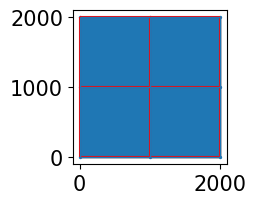

In [65]:
# 可视化地理数据
plot_gdf(gdf)
plt.show()

In [36]:
gdf.to_file('init_grid3_200.geojson', driver='GeoJSON')

In [38]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 加载 GeoJSON 文件
gdf = gpd.read_file('init_grid3_200.geojson')

ValueError: aspect must be finite and positive 

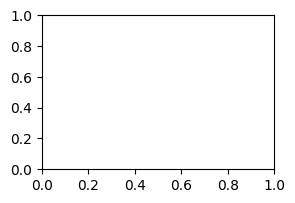

In [39]:
plot_gdf(gdf)

In [66]:
d=dict()
d['gdf'] = gdf
with open('./init_plan_grid3.pickle', 'wb') as f:
    pickle.dump(d, f)

In [55]:
d= pickle.load(open('init_plan_grid3.pickle', 'rb'))

In [56]:
gdf= d['gdf']

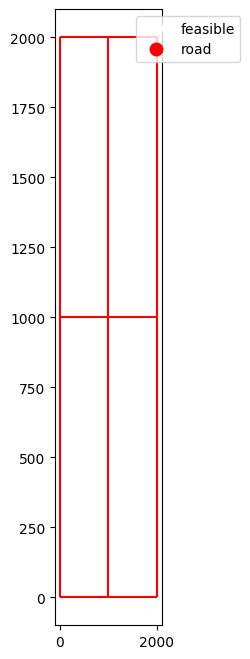

In [57]:
env.load_plan(gdf)
env.visualize()